#Library

In [1]:
import pandas as pd
import os
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#Read File

In [2]:
label = pd.read_csv('/content/drive/Shareddrives/Machine Learning/final_dataset.csv')
label.head()

,image,label,path
0,001.jpg,0,/content/drive/Shareddrives/Machine Learning/O...
1,002.jpg,0,/content/drive/Shareddrives/Machine Learning/O...
2,003.jpg,0,/content/drive/Shareddrives/Machine Learning/O...
3,004.jpg,0,/content/drive/Shareddrives/Machine Learning/O...
4,005.jpg,0,/content/drive/Shareddrives/Machine Learning/O...


#EDA

In [4]:
folder_utama = "/content/drive/Shareddrives/Machine Learning"
total_gambar = 0

for folder in os.listdir(folder_utama):
    folder_path = os.path.join(folder_utama, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(folder_path, file)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                total_gambar += 1

print(f"Total Gambar: {total_gambar}")

Total Gambar: 2417


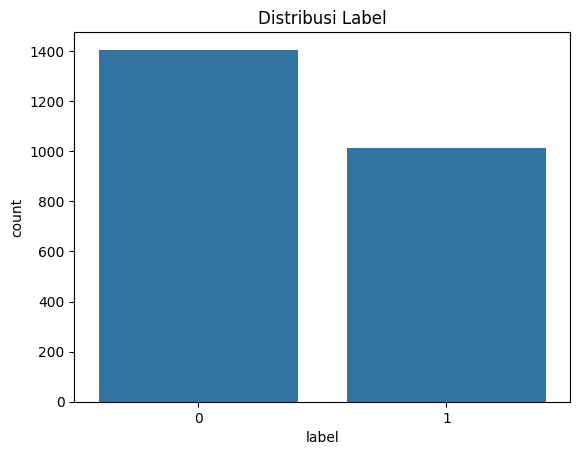

label
0    1405
1    1012
Name: count, dtype: int64


In [5]:
sns.countplot(x='label', data=label)
plt.title("Distribusi Label")
plt.show()
print(label['label'].value_counts())

#Split Data

In [6]:
train_df, test_df = train_test_split(
    label,
    test_size=0.2,
    stratify=label["label"],
    random_state=42
)

In [7]:
print("Train:")
print(train_df["label"].value_counts())

print("\nTest:")
print(test_df["label"].value_counts())

Train:
label
0    1124
1     809
Name: count, dtype: int64

Test:
label
0    281
1    203
Name: count, dtype: int64


#Preprocessing

###Resize + BGR to RGB + CLAHE Green Chanel Data Train

In [8]:
import cv2
import numpy as np

x_train = []
y_train = []

for _, row in train_df.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    green = img[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    img[:, :, 1] = clahe.apply(green)

    x_train.append(img)
    y_train.append(row["label"])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(np.bincount(y_train))

(1933, 224, 224, 3)
[1124  809]


###Augmentasi Label 1 Data Train

In [9]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

need = 315

minority = x_train[y_train == 1]

aug = []

while len(aug) < need:
    img = minority[np.random.randint(len(minority))]
    aug.append(next(datagen.flow(img[None], batch_size=1))[0])

x_train = np.concatenate([x_train, np.array(aug)])
y_train = np.concatenate([y_train, np.ones(len(aug), dtype=int)])

print(np.bincount(y_train))

[1124 1124]


###Resize + BGR to RGB + CLAHE Green Chanel Data Test

In [10]:
x_test = []
y_test = []

for _, row in test_df.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    green = img[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    img[:, :, 1] = clahe.apply(green)

    x_test.append(img)
    y_test.append(row["label"])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(np.bincount(y_test))

(484, 224, 224, 3)
[281 203]


###Visualisasi Sebelum dan Sesudah Preprocessing

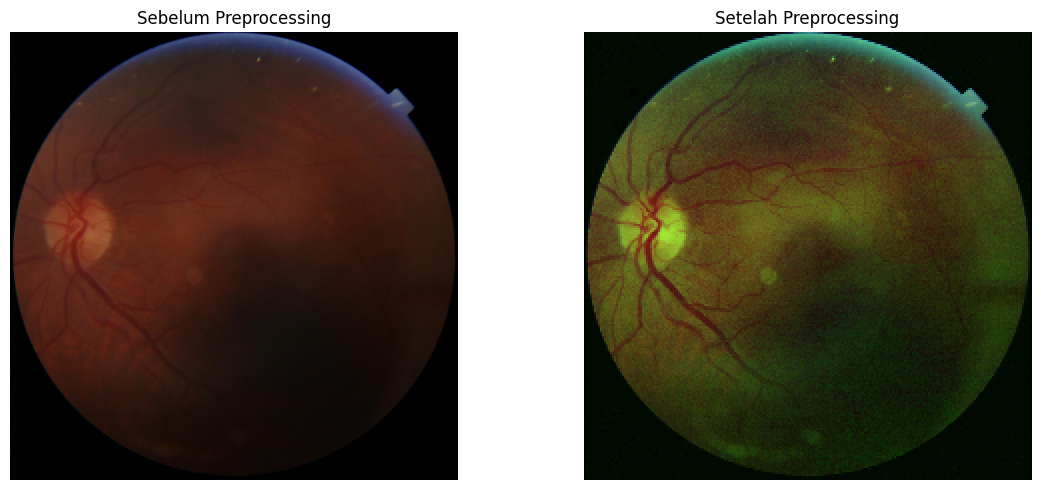

In [11]:
import cv2
import matplotlib.pyplot as plt

img_path = train_df.iloc[0]["path"]

# Original
img_ori = cv2.imread(img_path)
img_ori = cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB)

# Preprocessing
img_pre = cv2.resize(img_ori.copy(), (224, 224))

green = img_pre[:, :, 1]
clahe = cv2.createCLAHE(
    clipLimit=4.0,
    tileGridSize=(8,8)
)

img_pre[:, :, 1] = clahe.apply(green)

# Visualisasi
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_ori)
plt.title("Sebelum Preprocessing")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_pre)
plt.title("Setelah Preprocessing")
plt.axis("off")

plt.tight_layout()
plt.show()

#Feature Extraction

###MobileNetV3

In [12]:
mobilenet = MobileNetV3Large(weights="imagenet", include_top=False, pooling="avg", input_shape=(224, 224, 3))

feature_train = mobilenet.predict(preprocess_input(x_train), batch_size=32, verbose=1)
feature_test = mobilenet.predict(preprocess_input(x_test), batch_size=32, verbose=1)

print(feature_train.shape)
print(feature_test.shape)

71/71 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step
(2248, 960)
(484, 960)


#Model

###Multi Layer Perceptron

In [13]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42)
mlp.fit(feature_train, y_train)
pred_mlp = mlp.predict(feature_test)

print("Accuracy :", accuracy_score(y_test, pred_mlp))
print(classification_report(y_test, pred_mlp))

Accuracy : 0.731404958677686
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       281
           1       0.70      0.64      0.66       203

    accuracy                           0.73       484
   macro avg       0.72      0.72      0.72       484
weighted avg       0.73      0.73      0.73       484



###Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(feature_train, y_train)
pred_rf = rf.predict(feature_test)

print("Accuracy :", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy : 0.7747933884297521
              precision    recall  f1-score   support

           0       0.75      0.92      0.83       281
           1       0.84      0.57      0.68       203

    accuracy                           0.77       484
   macro avg       0.79      0.75      0.75       484
weighted avg       0.79      0.77      0.77       484



###XGBoost

In [15]:
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(feature_train, y_train)
pred_xgb = xgb.predict(feature_test)

print("Accuracy :", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))

Accuracy : 0.78099173553719
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       281
           1       0.84      0.59      0.69       203

    accuracy                           0.78       484
   macro avg       0.80      0.75      0.76       484
weighted avg       0.79      0.78      0.77       484



###Perbandingan Hasil

In [16]:
hasil = pd.DataFrame({
    "Model": ["MLP", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, pred_mlp), accuracy_score(y_test, pred_rf), accuracy_score(y_test, pred_xgb)],
    "Precision": [precision_score(y_test, pred_mlp), precision_score(y_test, pred_rf), precision_score(y_test, pred_xgb)],
    "Recall": [recall_score(y_test, pred_mlp), recall_score(y_test, pred_rf), recall_score(y_test, pred_xgb)],
    "F1-Score": [f1_score(y_test, pred_mlp), f1_score(y_test, pred_rf), f1_score(y_test, pred_xgb)]})

hasil

,Model,Accuracy,Precision,Recall,F1-Score
0,MLP,0.731405,0.697297,0.635468,0.664948
1,Random Forest,0.774793,0.840580,0.571429,0.680352
2,XGBoost,0.780992,0.839161,0.591133,0.693642
